In [43]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import pandas as pd
import polars as pl
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from sklearn.cluster import DBSCAN, HDBSCAN

import sys
sys.path.append("..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter(dark_background=True)

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions
S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SRes_F = SR_Functions.SuperRes_Functions()

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

import types
smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma" :  1.5}
smoothing_function.extent =  1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [44]:
#data_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/old/'
data_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/Ximea_Calibration/'
#data_folder = r'C:\Users\jsb92\Cambridge University Dropbox\Joseph Beckwith\Chemistry\Lee\Data\Salix\Ximea_Calibration'
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()


In [45]:
objective_T = S_F.getobjectiveefficiency(wavelength)

In [46]:
wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])

In [47]:
dye_data_folders = np.array([r'/media/jbeckwith/Ezra Seagat/JSB/20250609_dyes/data/100nMLD655_PLL_40mW638_TIRF_bothlasers_405488561638di_638LP_1/',
                             r'/media/jbeckwith/Ezra Seagat/JSB/20250507_4Dyes/data/CF680_reappliedOil/CF680_60mW655_LP638_SP785_1/',
                             r'/media/jbeckwith/Ezra Seagat/JSB/20250507_4Dyes/data/CF500/CF500_40mW_LP488_BP520-44_SP785_1/',
                             r'/media/jbeckwith/Ezra Seagat/JSB/20250507_4Dyes/data/ATTO488/ATTO488_40mW_LP488_BP520-44_SP785_1/',
                            r'/media/jbeckwith/Ezra Seagat/JSB/20250325 Ximea camera install/BODIPY_493_503_100pM_PVA/BODIPY_493_503_40mW_488_LP488_BP_520_44_Scan2_2/',
                            r'/media/jbeckwith/Ezra Seagat/JSB/20250507_4Dyes/data/LD655/LD655_20mW655_LP638_SP785_1/',
                            '/media/jbeckwith/Ezra Seagat/JSB/20250325 Ximea camera install/ATTO_565_100pMPVA_10mW_561/Atto565_10mW_561_lp561_bp_582_64_5_Scan_1/'])

In [72]:
example_folder = dye_data_folders[-1]

In [73]:
example_folder

'/media/jbeckwith/Ezra Seagat/JSB/20250325 Ximea camera install/ATTO_565_100pMPVA_10mW_561/Atto565_10mW_561_lp561_bp_582_64_5_Scan_1/'

In [74]:
localisation_files = H_F.file_search(example_folder, '.h5', 'Pos')

In [75]:
analysis_files = H_F.file_search(example_folder, '.h5', 'database')

In [76]:
analysis_files

array(['/media/jbeckwith/Ezra Seagat/JSB/20250325 Ximea camera install/ATTO_565_100pMPVA_10mW_561/Atto565_10mW_561_lp561_bp_582_64_5_Scan_1/Single_frame_database.h5',
       '/media/jbeckwith/Ezra Seagat/JSB/20250325 Ximea camera install/ATTO_565_100pMPVA_10mW_561/Atto565_10mW_561_lp561_bp_582_64_5_Scan_1/Single_molecule_database.h5'],
      dtype='<U159')

In [71]:
single_molecule_database_CF500 = pd.read_hdf(analysis_files[1])

In [77]:
single_molecule_database_ATTO565 = pd.read_hdf(analysis_files[1])

In [64]:
#single_frame_database = pd.read_hdf(analysis_files[0])
single_molecule_database_LD655 = pd.read_hdf(analysis_files[1])

In [30]:
def average_parameters(data, dbscan_labels):
    labels = np.sort(np.unique(dbscan_labels))
    labels = labels[labels > -1]
    dict_obj = {}
    dict_obj['photons'] = np.zeros(len(labels))
    dict_obj['frames'] = np.zeros(len(labels))
    for column in np.array(data.columns):
        if column == 'index':
            continue
        else:
            dict_obj[column] = np.zeros(len(labels))
    
    for label in labels:
        for column in np.array(data.columns):
            if column == 'index':
                continue
            elif column in ['A_B', 'A_G', 'A_R']:
                dict_obj[column][label] = np.sum(data[column][dbscan_labels == label])
            else:
                dict_obj[column][label] = np.mean(data[column][dbscan_labels == label])
        dict_obj['frames'][label] = len(data[column][dbscan_labels == label])
        dict_obj['photons'][label] = np.sum(data['A_B'][dbscan_labels == label]) + np.sum(data['A_G'][dbscan_labels == label]) + np.sum(data['A_R'][dbscan_labels == label])
    dict_obj['A_B'] = dict_obj['A_B']/dict_obj['photons']
    dict_obj['A_G'] = dict_obj['A_G']/dict_obj['photons']
    dict_obj['A_R'] = dict_obj['A_R']/dict_obj['photons']
    df = pd.DataFrame.from_dict(dict_obj)
    return df

In [31]:
def collect_traces(data, dbscan_labels, image_stack, image_size=12):
    labels = np.sort(np.unique(dbscan_labels))
    labels = labels[labels > -1]
    trace_matrix = np.zeros([len(labels), image_stack.shape[0]])
    locations = np.zeros([2, len(labels)])

    for i, label in enumerate(labels):
        locations[0, i] = np.nanmean(data['xc'][dbscan_labels == label].to_numpy())
        locations[1, i] = np.nanmean(data['yc'][dbscan_labels == label].to_numpy())
        xmin = int(locations[0, i])-int(image_size/2)
        xmax = int(locations[0, i])+int(image_size/2)
        ymin = int(locations[1, i])-int(image_size/2)
        ymax = int(locations[1, i])+int(image_size/2)
        trace_matrix[i, :] = np.sum(np.sum(image_stack[:, xmin:xmax, ymin:ymax], axis=-1), axis=-1)
        print(
                "Summed trace {}/{}".format(
                    i + 1, len(labels)
                ),
                end="\r",
                flush=True,
            )

    return locations, trace_matrix

In [27]:
def extract_single_molecules(localisation_files, chi_val=None):
    columns = ['xc', 'yc', 's_x', 's_y', 'bg_B', 'bg_G', 'bg_R', 'A_B', 'A_G', 'A_R',
       'chi_sqr', 'frame', 'xc_err', 'yc_err', 's_x_err', 's_y_err',
       'bg_B_err', 'bg_G_err', 'bg_R_err', 'A_B_err', 'A_G_err', 'A_R_err']

    for i, file in enumerate(localisation_files):
        loc_data = pd.read_hdf(file, columns=columns)
        if chi_val is None:
            chi_val = np.median(loc_data['chi_sqr'])
        loc_data = loc_data[loc_data['chi_sqr'] < chi_val]
        loc_data = loc_data[loc_data['xc_err'] < 1]
        loc_data = loc_data[loc_data['yc_err'] < 1]
        loc_data = loc_data[loc_data['A_B']+loc_data['A_G']+loc_data['A_R'] < 10000]
        loc_data = loc_data[loc_data['A_B']+loc_data['A_G']+loc_data['A_R'] > 500]
        loc_data = loc_data.reset_index()
        X = np.vstack([loc_data['xc'], loc_data['yc']]).T
        loc_precision = 0.5*(np.mean(loc_data['xc_err']) + np.mean(loc_data['yc_err']))
        hdb = HDBSCAN(min_cluster_size=10, cluster_selection_epsilon=loc_precision)
        hdb.fit(X)
        df = average_parameters(loc_data, hdb.labels_)
        photons = loc_data['A_B']+loc_data['A_G']+loc_data['A_R']
        loc_data['photons'] = photons
        for column in np.array(loc_data.columns):
            if column in ['A_B', 'A_G', 'A_R']:
                loc_data[column] = loc_data[column]/photons
        if i == 0:
            single_frame_database = loc_data
            single_molecule_database = df
        else:
            single_frame_database = pd.concat([single_frame_database, loc_data])
            single_molecule_database = pd.concat([single_molecule_database, df])
    return single_molecule_database.reset_index(), single_frame_database.reset_index()

In [28]:
def extract_single_molecule_traces(localisation_file, chi_val=None):
    columns = ['xc', 'yc', 's_x', 's_y', 'bg_B', 'bg_G', 'bg_R', 'A_B', 'A_G', 'A_R',
       'chi_sqr', 'frame', 'xc_err', 'yc_err', 's_x_err', 's_y_err',
       'bg_B_err', 'bg_G_err', 'bg_R_err', 'A_B_err', 'A_G_err', 'A_R_err']

    image_file = localisation_file.split('.')[0]+'.ome.tif'
    metadata = localisation_file.split('.')[0]+'_metadata.txt'
    x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata)
    image_data, _, _ = IO.read_tiff_tophotoelectrons(image_file, smoothing_function, gain_map=gain[x_coord:x_coord+width, y_coord:y_coord+height], offset_map=offset[x_coord:x_coord+width, y_coord:y_coord+height], rqe=rqe[x_coord:x_coord+width, y_coord:y_coord+height], read_noise=readnoise[x_coord:x_coord+width, y_coord:y_coord+height], frame=np.arange(750))
    loc_data = pd.read_hdf(localisation_file, columns=columns)
    if chi_val is None:
        chi_val = np.median(loc_data['chi_sqr'])
    loc_data = loc_data[loc_data['chi_sqr'] < chi_val]
    loc_data = loc_data[loc_data['xc_err'] < 1]
    loc_data = loc_data[loc_data['yc_err'] < 1]
    loc_data = loc_data[loc_data['A_B']+loc_data['A_G']+loc_data['A_R'] < 10000]
    loc_data = loc_data[loc_data['A_B']+loc_data['A_G']+loc_data['A_R'] > 500]
    loc_data = loc_data.reset_index()
    X = np.vstack([loc_data['xc'], loc_data['yc']]).T
    loc_precision = 0.5*(np.mean(loc_data['xc_err']) + np.mean(loc_data['yc_err']))
    hdb = DBSCAN(min_samples=10, eps=loc_precision)
    hdb.fit(X)
    locations, trace_matrix = collect_traces(loc_data, hdb.labels_, image_data)
    return locations, trace_matrix, image_data

In [ ]:
locations, trace_matrix, image_data = extract_single_molecule_traces(localisation_files[0], 2)

In [ ]:
# good traces
# 80
# 123
# 47

In [ ]:
locations_forplot = locations[:, [80, 47, 123]]
trace_matrix_forplot = trace_matrix[ [80, 47, 123], :]
trace_matrix_forplot = trace_matrix_forplot.T - np.min(trace_matrix_forplot, axis=1)
trace_matrix_forplot = trace_matrix_forplot.T

In [ ]:
fig, axs = plotter.two_column_plot(ncolumns=3, nrows=2, widthratio=[1,1,1], heightratio=[1,1], height=6, width=9)

folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Conference Presentations/20250627_RSCPhotochem/fig/multicolour_camera/dyes/'
plotter.make_animated_gif_bleaching(fig, axs, locations_forplot, trace_matrix_forplot, image_data[:450, :, :], 
                                    14, np.linspace(0, 749*0.1, 750)[:450], os.path.join(folder, 'LD655_bleaching.gif'))

In [ ]:
plt.plot(trace_matrix[80, :])
plt.xlim([0, 60])

In [54]:
single_molecule_database, single_frame_database = extract_single_molecules(localisation_files)

In [55]:
single_frame_database.to_hdf(os.path.join(example_folder, 'Single_frame_database.h5'), key='data', format="table")

In [56]:
single_molecule_database.to_hdf(os.path.join(example_folder, 'Single_molecule_database.h5'), key='data', format="table")

In [13]:
notch_filter = 'semrock-nf03-405-488-561-635e'
dichroic_mirror = 'semrock-di03-r405-488-561-635-t1-25x36'
dichroic_mirror_561 = 'semrock-di03-r488-561-t1-25x36'

shortpass_filter = 'semrock-bsp01-785r'
longpass_red_filter = 'semrock-blp01-635r'
longpass_561_filter = 'semrock-blp01-561r'

longpass_blue_filter = 'semrock-blp01-488r'
bandpass_488_filter = 'semrock-ff01-520-44'
bandpass_561_filter = 'semrock-ff01-582-64'

filters = [longpass_561_filter, dichroic_mirror_561, bandpass_561_filter]
dye = 'ATTO 565'
average_emission_wavelengths, dye_pixel_efficiency = S_F.get_pixel_fractions_dye_and_filters(dye, filters, wavelength, pixel_QYs)
dye_pixel_efficiency = dye_pixel_efficiency/np.sum(dye_pixel_efficiency)

In [14]:
LD655 = S_F.get_dye_or_filter_data(dye, wavelength)
filter = np.prod(S_F.get_dye_or_filter_data(filters, wavelength, dye_or_filter=False), axis=0)

In [15]:
filter = filter*objective_T

In [16]:
average_emission_wavelengths, dye_pixel_efficiency = S_F.get_pixel_fractions_rawspectra(LD655*filter, wavelength, pixel_QYs)


In [17]:
filters = S_F.get_dye_or_filter_data(filters, wavelength, dye_or_filter=False)

In [ ]:
fig, axs = plotter.one_column_plot(npanels=2, ratios=[1,1], height=5)

ax2 = axs[0].twinx()  # instantiate a second Axes that shares the same x-axis
ax2.set_ylabel('transmission/%', color='#ffc0cb')  # we already handled the x-label with ax1

linestyles = np.array(['--', '-.', ':'])
for i in np.arange(len(filters)):
    if i != 2:
        ax2.plot(wavelength, 100*filters[i, :], color='#ffc0cb', lw=0.5, ls=linestyles[i])
    if i == 2:
        ax2.plot(wavelength, 100*filters[i, :], color='#ffc0cb', lw=0.5, ls=linestyles[i], label='microscope filters')
        
ax2.set_ylim([0, 110])
ax2.legend(loc='best')


axs[0] = plotter.line_plot(axs=axs[0], x=wavelength, y=np.squeeze(LD655)/np.max(LD655), color='white', xaxislabel='wavelength/nm', yaxislabel='fluo/norm', label='LD 655')

axs[0].set_ylim(0, 1.1)
axs[0].set_xlim(550, 800)
axs[0].legend(loc='best')

axs[1] = plotter.line_plot(axs=axs[1], x=wavelength, y=np.squeeze(filtered_L655)/np.max(filtered_L655), color='white', xaxislabel='wavelength/nm', yaxislabel='fluo/norm', label='LD 655 after filters')
axs[1].legend(loc='best')

axs[1].set_ylim(0, 1.05)
axs[1].set_xlim(550, 800)

folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Conference Presentations/20250627_RSCPhotochem/fig/multicolour_camera/dyes/'
plt.savefig(os.path.join(folder, 'LD655_Spectra.svg'), dpi=600)
plt.show()

In [ ]:
plt.plot(wavelength, filter.T, color='white')

In [18]:
cf500_maxt = 0.25
cf500_maxl = 0.9
cf500_maxr = 0.35
cf500_ts = 0.25

bodipy_maxl = 1
bodipy_maxt = 0.45
bodipy_maxr = 0.45
bodipy_ts = 0.45

ld655_maxt = 0.85
ld655_maxl = 0.35
ld655_maxr = 0.2
ld655_ts=0.2

atto565_maxt = 0.9
atto565_maxl = 0.7
atto565_maxr = 0.5
atto565_ts=0.5

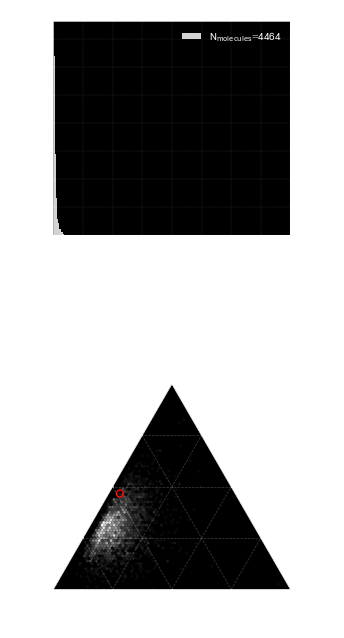

In [85]:
fig, ax = plotter.one_column_plot(npanels=2, ratios=[0.5, 1])


fig, ax = plotter.ternary_contour_plot(fig, ax, single_molecule_database_ATTO565['A_R'], single_molecule_database_ATTO565['A_G'], single_molecule_database_ATTO565['A_B'], 
                                       gridsize=200,
                                  R=dye_pixel_efficiency[2], G=dye_pixel_efficiency[1], B=dye_pixel_efficiency[0], maxt=atto565_maxt, 
                                       maxl=atto565_maxl, 
                                maxr=atto565_maxr, trianglesize=atto565_ts,
                                       maj_loc=0.2,
                                       min_loc=0.1,
                                 lws=1,
                                 ecolour='red')

n_molecules = len(single_molecule_database['photons'])
ax[0] = plotter.histogram_plot(axs=ax[0], data=single_molecule_database['photons'], bins=np.histogram_bin_edges(single_molecule_database['photons'], 'fd'), histcolor='#d3d3d3', xaxislabel='photons per molecule', label=r'N$_\mathsf{molecules}$='+str(int(n_molecules)))
ax[0].set_xlim([0, 2e6])
ax[0].legend(loc='best', frameon=False)

folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Conference Presentations/20250627_RSCPhotochem/fig/multicolour_camera/dyes/'
plt.savefig(os.path.join(folder, 'ATTO565_permolecule_objective.svg'), dpi=600)
plt.show()

In [87]:
sm_all = pd.concat([single_molecule_database_CF500, single_molecule_database_LD655, single_molecule_database_ATTO565])

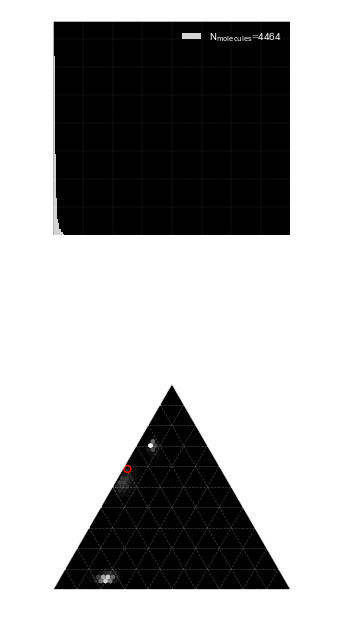

In [90]:
fig, ax = plotter.one_column_plot(npanels=2, ratios=[0.5, 1])


fig, ax = plotter.ternary_contour_plot(fig, ax, sm_all['A_R'], sm_all['A_G'], sm_all['A_B'], 
                                       gridsize=50,
                                  R=dye_pixel_efficiency[2], G=dye_pixel_efficiency[1], B=dye_pixel_efficiency[0], maxt=1, 
                                       maxl=1, 
                                maxr=1, trianglesize=1,
                                       maj_loc=0.2,
                                       min_loc=0.1,
                                 lws=1,
                                 ecolour='red')

n_molecules = len(single_molecule_database['photons'])
ax[0] = plotter.histogram_plot(axs=ax[0], data=single_molecule_database['photons'], bins=np.histogram_bin_edges(single_molecule_database['photons'], 'fd'), histcolor='#d3d3d3', xaxislabel='photons per molecule', label=r'N$_\mathsf{molecules}$='+str(int(n_molecules)))
ax[0].set_xlim([0, 2e6])
ax[0].legend(loc='best', frameon=False)

folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Conference Presentations/20250627_RSCPhotochem/fig/multicolour_camera/dyes/'
plt.savefig(os.path.join(folder, 'All_permolecule_objective.svg'), dpi=600)
plt.show()

In [ ]:
fig, ax = plotter.one_column_plot(npanels=2, ratios=[0.5, 1])


fig, ax = plotter.ternary_contour_plot(fig, ax, single_frame_database['A_R'], single_frame_database['A_G'], single_frame_database['A_B'], 
                                       gridsize=100,
                                  R=dye_pixel_efficiency[2], G=dye_pixel_efficiency[1], B=dye_pixel_efficiency[0], maxt=bodipy_maxt, 
                                       maxl=bodipy_maxl, 
                                maxr=bodipy_maxr, trianglesize=bodipy_ts,
                                       maj_loc=0.2,
                                       min_loc=0.1,
                                 lws=1,
                                 ecolour='red')

n_molecules = len(single_frame_database['photons'])
ax[0] = plotter.histogram_plot(axs=ax[0], data=single_frame_database['photons'], bins=np.histogram_bin_edges(single_frame_database['photons'], 'fd'), histcolor='#d3d3d3', xaxislabel='photons per frame', label=r'N$_\mathsf{molecules}$='+str(int(n_molecules)))

ax[0].legend(loc='best', frameon=False)

folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Conference Presentations/20250627_RSCPhotochem/fig/multicolour_camera/dyes/'
#plt.savefig(os.path.join(folder, 'BODIPY_PVA_perframe.svg'), dpi=600)
plt.show()